## Librerias

In [2]:

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


## Cargar Dataset

In [3]:
df = pd.read_csv("Adopción_de_la_zonificación_de_la_producción_de_carne_bovina_en_pastoreo_para_el_mercado_nacional_y_de_exportación,_en_el_departamento_de_La_Guajira._20250915.csv")


In [4]:
df.head()

,the_geom,Municipio,Departamento,Código departamento,Código municipio,Gridcode,Aptitud,Área (ha),Consecutivo
0,MULTIPOLYGON (((-73.00736616834294 10.56002451...,Urumita,La Guajira,44,44855,0,No apta,"11,677.37",31
1,MULTIPOLYGON (((-72.91600845748357 10.60465894...,Villanueva,La Guajira,44,44874,0,No apta,"9,948.54",73
2,MULTIPOLYGON (((-73.07286681175579 10.61467517...,Villanueva,La Guajira,44,44874,0,No apta,"1,288.26",79
3,MULTIPOLYGON (((-72.85101803256207 10.74133271...,San Juan del Cesar,La Guajira,44,44650,0,No apta,"7,068.29",194
4,MULTIPOLYGON (((-72.7814801880347 10.611536830...,El Molino,La Guajira,44,44110,0,No apta,0.00,101


## Validacion de datos

In [5]:
# Revisar valores nulos
faltantes = df.isnull().sum()

# Revisar duplicados
duplicados = df.duplicated().sum()

tabla_validacion = pd.DataFrame({
    "Valores Faltantes": faltantes,
    "Duplicados": [duplicados] + [""]*(len(faltantes)-1)
})

tabla_validacion

,Valores Faltantes,Duplicados
the_geom,0,0
Municipio,0,
Departamento,0,
Código departamento,0,
Código municipio,0,
Gridcode,0,
Aptitud,0,
Área (ha),0,
Consecutivo,0,


## Preparacion del dataset

In [6]:
df["Código municipio"] = df["Código municipio"].astype(str).str.zfill(5)
df["Código departamento"] = df["Código departamento"].astype(str).str.zfill(2)


## Revisar las columnas

In [7]:
df.columns

Index(['the_geom', 'Municipio', 'Departamento', 'Código departamento',
       'Código municipio', 'Gridcode', 'Aptitud', 'Área (ha)', 'Consecutivo'],
      dtype='object')

## Creacion del Shapefile

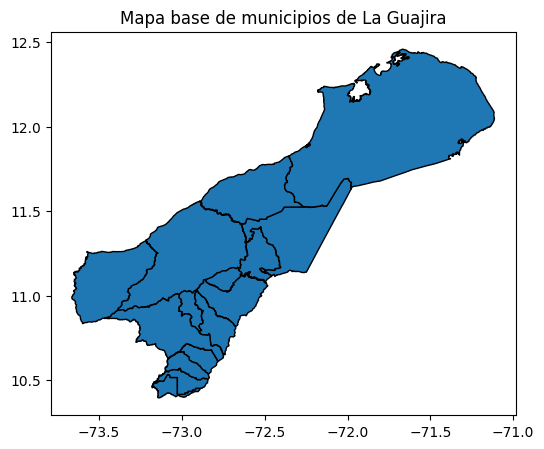

In [9]:
# Cargar shapefile de municipios 
shapefile = gpd.read_file("C:/Users/mateo/Downloads/visualStudio/visualizacion/Georeferenciacion/docs/MGN2024_MPIO_POLITICO")

# Filtrar solo el departamento de La Guajira (código 44)
shapefile = shapefile[shapefile["dpto_ccdgo"] == "44"]

shapefile.plot(edgecolor="black", figsize=(6,6))
plt.title("Mapa base de municipios de La Guajira")
plt.show()

## Union del datset con el Shapefile

In [10]:
# Unir por código de municipio
gdf = shapefile.merge(df, left_on="mpio_cdpmp", right_on="Código municipio")

# Convertir a GeoDataFrame asegurando geometría
gdf = gpd.GeoDataFrame(gdf, geometry="geometry")

gdf.head()

,dpto_ccdgo,mpio_ccdgo,mpio_cdpmp,dpto_cnmbr,mpio_cnmbr,mpio_crslc,mpio_tipo,mpio_narea,mpio_nano,shape_Leng,...,geometry,the_geom,Municipio,Departamento,Código departamento,Código municipio,Gridcode,Aptitud,Área (ha),Consecutivo
0,44,001,44001,LA GUAJIRA,RIOHACHA,1954,MUNICIPIO,3088.634786,2024,3.03059,...,"POLYGON ((-72.89025 11.55973, -72.89003 11.559...",MULTIPOLYGON (((-73.04962111720182 11.26270098...,Riohacha,La Guajira,44,44001,0,No apta,"218,496.48",518
1,44,001,44001,LA GUAJIRA,RIOHACHA,1954,MUNICIPIO,3088.634786,2024,3.03059,...,"POLYGON ((-72.89025 11.55973, -72.89003 11.559...",MULTIPOLYGON (((-73.16357452252308 11.34440559...,Riohacha,La Guajira,44,44001,0,No apta,0.00,529
2,44,001,44001,LA GUAJIRA,RIOHACHA,1954,MUNICIPIO,3088.634786,2024,3.03059,...,"POLYGON ((-72.89025 11.55973, -72.89003 11.559...",MULTIPOLYGON (((-73.11195788762656 11.24212027...,Riohacha,La Guajira,44,44001,0,No apta,0.80,549
3,44,001,44001,LA GUAJIRA,RIOHACHA,1954,MUNICIPIO,3088.634786,2024,3.03059,...,"POLYGON ((-72.89025 11.55973, -72.89003 11.559...",MULTIPOLYGON (((-73.15947156542802 10.98878338...,Riohacha,La Guajira,44,44001,0,No apta,"1,054.44",616
4,44,001,44001,LA GUAJIRA,RIOHACHA,1954,MUNICIPIO,3088.634786,2024,3.03059,...,"POLYGON ((-72.89025 11.55973, -72.89003 11.559...",MULTIPOLYGON (((-73.09447394012773 11.04672087...,Riohacha,La Guajira,44,44001,1,Aptitud baja,"4,058.14","1,911"


## Mapa 1: Aptitud (Apta / No apta)

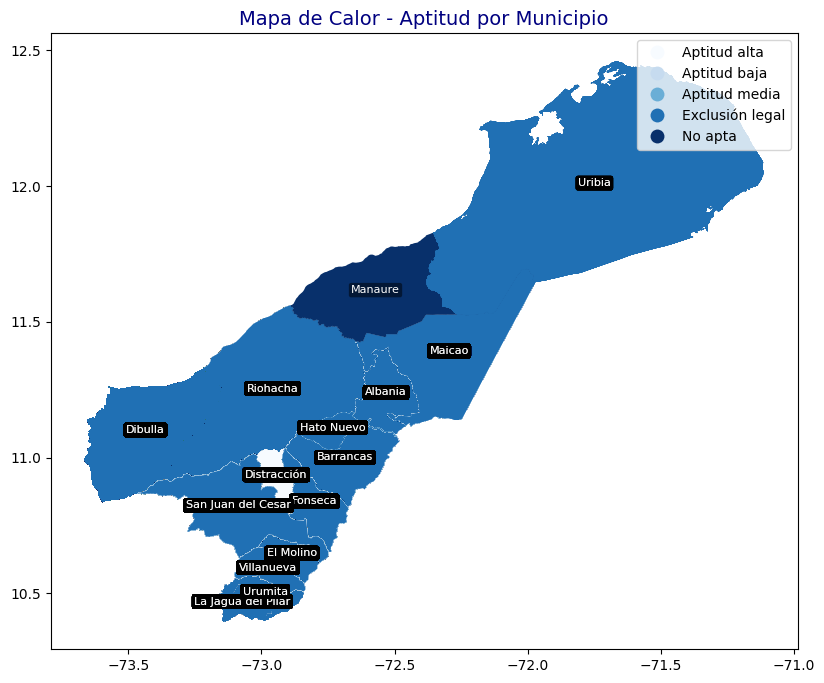

In [19]:
fig, ax = plt.subplots(figsize=(12,8))

# Mapa con paleta azul
gdf.plot(column="Aptitud", cmap="Blues", legend=True, ax=ax)

# Etiquetas más visibles
for idx, row in gdf.iterrows():
    plt.annotate(
        text=row["Municipio"], 
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        fontsize=8,  # más grande
        color="white",  # letras blancas
        ha="center",
        bbox=dict(facecolor="black", alpha=0.5, edgecolor="none", boxstyle="round,pad=0.2")  # fondo negro semitransparente
    )

plt.title("Mapa de Calor - Aptitud por Municipio", fontsize=14, color="navy")
plt.show()


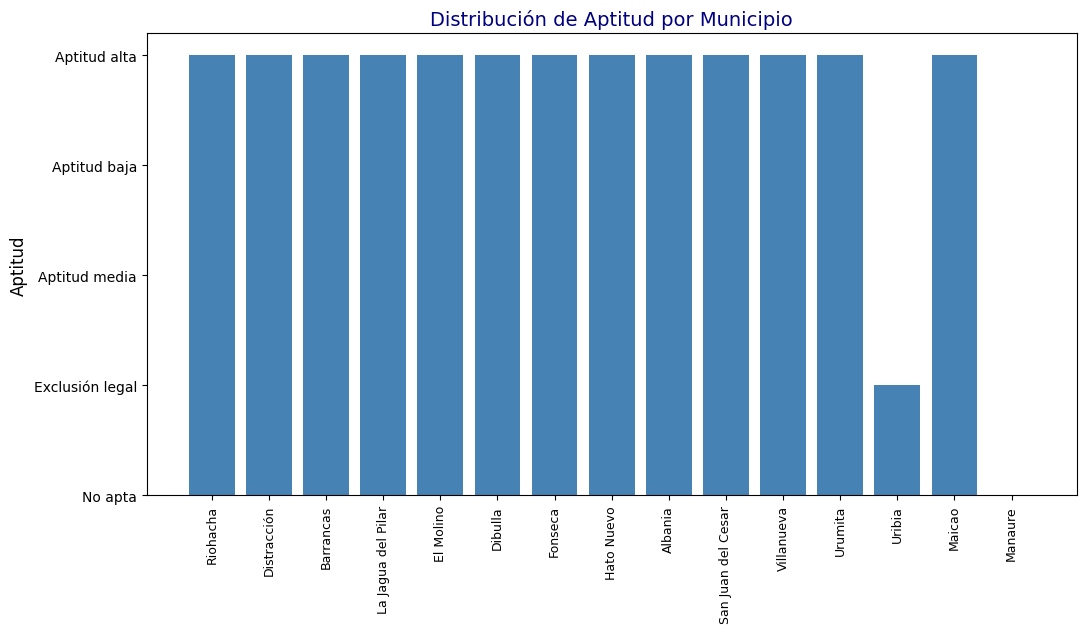

In [22]:
gdf_sorted = gdf.sort_values("Aptitud", ascending=False)

plt.figure(figsize=(12,6))
plt.bar(gdf_sorted["Municipio"], gdf_sorted["Aptitud"], color="steelblue")
plt.xticks(rotation=90, fontsize=9)
plt.ylabel("Aptitud", fontsize=12)
plt.title("Distribución de Aptitud por Municipio", fontsize=14, color="navy")
plt.show()


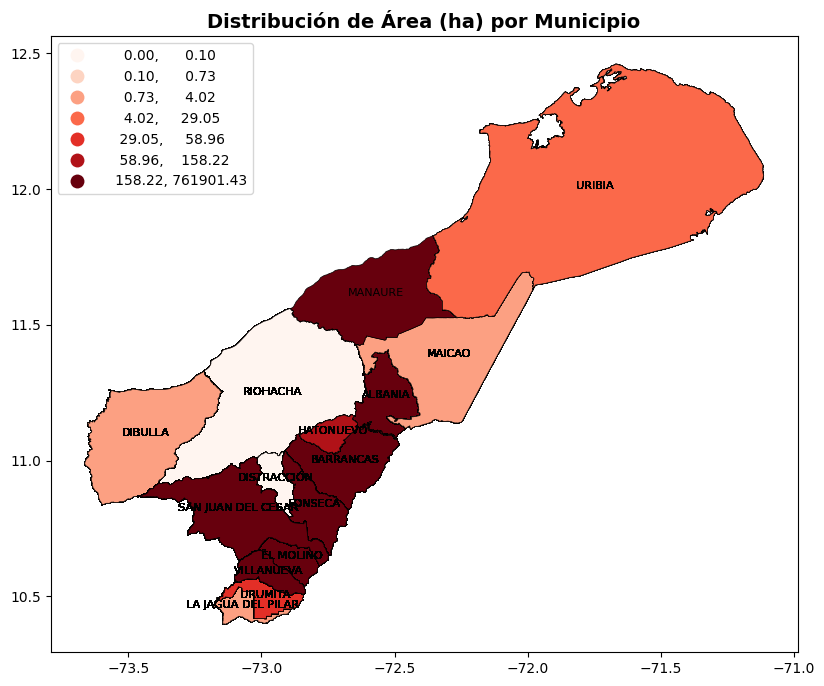

In [25]:
import mapclassify

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
gdf.plot(
    column="Área (ha)",
    cmap="Reds",
    scheme="Quantiles",
    k=7,
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)

# Agregar nombres de municipios en el centroide
for idx, row in gdf.iterrows():
    plt.annotate(
        text=row["mpio_cnmbr"], 
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha="center", fontsize=8, color="black"
    )

ax.set_title("Distribución de Área (ha) por Municipio", fontsize=14, fontweight="bold")
plt.show()


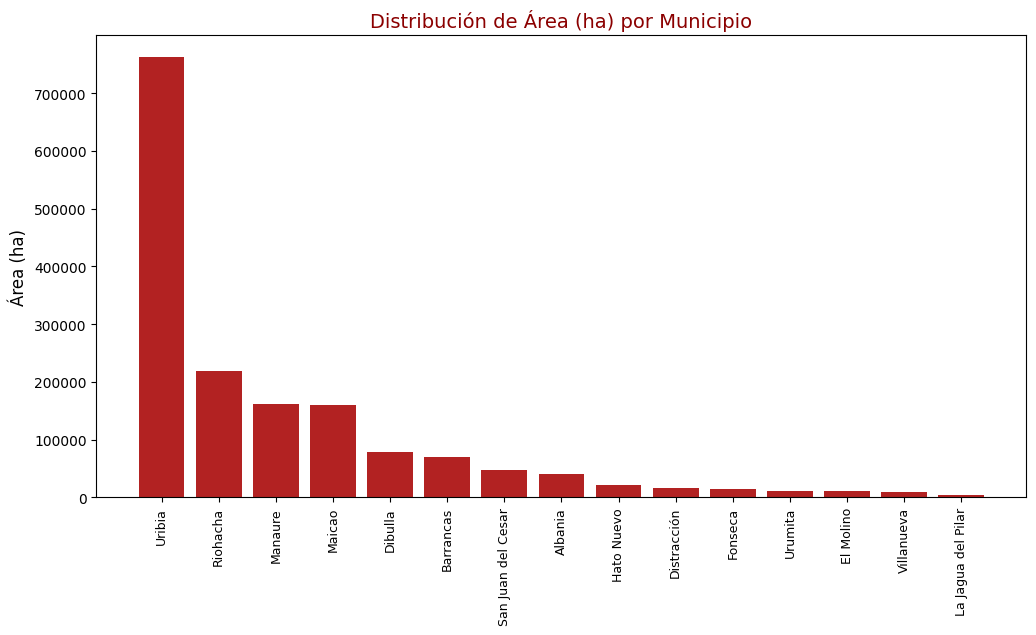

In [31]:
gdf_sorted = gdf.sort_values("Área (ha)", ascending=False)

plt.figure(figsize=(12,6))
plt.bar(gdf_sorted["Municipio"], gdf_sorted["Área (ha)"], color="firebrick")
plt.xticks(rotation=90, fontsize=9)
plt.ylabel("Área (ha)", fontsize=12)
plt.title("Distribución de Área (ha) por Municipio", fontsize=14, color="darkred")
plt.show()
